In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime
from tqdm import tqdm
from scipy.stats import mannwhitneyu, wilcoxon
import seaborn as sns
import statsmodels.api as sm

C:\Users\gpe9038\AppData\Local\Temp\ipykernel_12088\3480450186.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [248]:
common_config = {
    'dbname': 'db',
    'user': 'codespace',
    'host': 'localhost',
    'project': 'kfc-kiosk-3',
    'location': 'US',
    'query_id': 'bquxjob_159f1b6a_18cedf71333',
    'kiosk_path': '/workspaces/codespaces-blank/bquxjob_567f0b61_18cf4ee3d07.csv',
    'cc_path': '/workspaces/codespaces-blank/cc.xlsx',
    'kassa_path': '/workspaces/codespaces-blank/kassa.xlsx',
    'name': 'ab_test_2',
    'start_date': '2023-12-16',
    'data_collect_start_date': '2023-01-08',
    'data_collect_end_date': '2024-01-08',
    'lower_bound': 0,
    'upper_bound': 1
}

configurations = [
    {
        'slice_type': 'event_date, restraunt_id',
        'aggregator': 'orders',
        'MDE': 6, # %
        'alpha': 0.05,
        'beta': 0.2
    },
]
config = configurations[0]

#####
df = pd.read_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\real_data\data_20231001_20240224.csv')

# ПЕРЕИМЕНОВАТЬ
clusters = pd.read_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\real_data\clustered_results (25) - clustered_results (25) (2).csv')
clusters = clusters.rename(columns={'Combined_Cluster': 'strat', 'Group': 'group', 'avg_orders': 'orders'})[['restraunt_id', 'strat', 'group']]

# ПРЕПРОЦЕССИНГ
data = df.merge(clusters, on='restraunt_id')
data['event_date'] = data['event_date'].apply(lambda x: datetime.strptime(str(x), "%Y%m%d").strftime("%Y-%m-%d"))
grouped_size = clusters.groupby('strat').size().to_frame(name='strat_size')
clusters = pd.merge(clusters, grouped_size, on='strat')

print(data.columns)
data[config['aggregator']] = data[config['aggregator']].astype(np.float64)

np.random.seed(42)

print(data[config['aggregator']].isnull().sum(), data[config['aggregator']].isnull().count())

# КОНСТАНТЫ ДЛЯ Т-теста
t_alpha = stats.norm.ppf(1 - config['alpha'] / 2, loc=0, scale=1)
t_beta = stats.norm.ppf(1 - config['beta'], loc=0, scale=1)

# МОДЕЛИРОВАНИЕ ЭФФЕКТА
test_before = data[(data.group == 'Test') & (data.event_date < common_config['start_date'])][config['aggregator']]

control_before = data[(data.group == 'Control') & (data.event_date < common_config['start_date'])][config['aggregator']]

# Эффект 
effect = config['MDE']/100 * pd.concat([control_before, test_before]).mean()

test_after = data[(data.group == 'Test') & (data.event_date < common_config['start_date'])][config['aggregator']]

control_after = data[(data.group == 'Control') & (data.event_date < common_config['start_date'])][config['aggregator']] + effect

#### Расчет минимально детектированного эффекта по предполагаемой продолжительности дней ####
print(data[data['event_date'] > common_config['start_date']]['restraunt_id'].count()/data[data['event_date'] > common_config['start_date']]['restraunt_id'].nunique(), 'Среднее количество есторанов в день(измерений))')
print(data[data['event_date'] > common_config['start_date']]['restraunt_id'].count(), 'доступное число измерений')
print(data[data['event_date'] > common_config['start_date']]['event_date'].nunique(), 'Количество дней теста')

print('\n')

pred_test_duration = 59
print(pred_test_duration, ' - предположительное количество дней теста')
th_sample_size = pred_test_duration * data['restraunt_id'].nunique()
th_effect = np.sqrt(2 * int((t_alpha + t_beta) ** 2 * pd.concat([control_before, test_before]).var() / (th_sample_size)))

print(th_effect*100/pd.concat([control_before, test_before]).mean(), '% - теоретический минимальный эффект')
print(th_effect, ' - теоретический ожидаемый эффект')
print(th_sample_size, 'теоретический минимальный выборки')

print('\n')

#### Расчет размера выборки по MDE ####
sample_size = int(2 * (t_alpha + t_beta) ** 2 * pd.concat([control_before, test_before]).var() / effect ** 2)
print(config['MDE'], '% - ожидаемый эффект')
print(effect, ' - ожидаемый эффект')
print(sample_size, 'размер выборки')
print(sample_size / data['restraunt_id'].nunique(), ' - количество дней теста')
                
print('\n')
               
# ПРОВЕРКА
print('до')
print(control_before.mean())
print(test_before.mean())
print(control_before.var())
print(test_before.var())
print('после')
print(control_after.mean())
print(test_after.mean())
print(control_after.var())
print(test_after.var())

splitted_data = clusters[['restraunt_id', 'strat','group']].drop_duplicates().dropna().sort_values(['strat', 'group'])
#splitted_data.strat = 0

splitted_data.head(5)

Index(['Unnamed: 0', 'event_date', 'restraunt_id',
       'system_identification_only_showed', 'open_auth_count',
       'tap_email_count', 'tap_sms_count', 'sessions', 'orders', 'auth_orders',
       'conversion_rate', 'auth_conversion_rate', 'revenue',
       'avg_product_count', 'strat', 'group'],
      dtype='object')
0 6775
58.92 Среднее количество есторанов в день(измерений))
2946 доступное число измерений
62 Количество дней теста


59  - предположительное количество дней теста
5.473844351587571 % - теоретический минимальный эффект
16.852299546352718  - теоретический ожидаемый эффект
2950 теоретический минимальный выборки


6 % - ожидаемый эффект
18.472172532415982  - ожидаемый эффект
2459 размер выборки
49.18  - количество дней теста


до
308.88935721812436
306.84051036682615
52992.64457828983
53953.40859207982
после
327.36152975054034
306.84051036682615
52992.64457828982
53953.40859207982


,restraunt_id,strat,group
1,74021462,1,Control
2,74021211,1,Control
4,74220627,1,Control
0,74020660,1,Test
3,74021880,1,Test


In [242]:
first_type_errors = []
second_type_errors = []
sample_size_mean = []
strat_var_mean = []

deltas_aa = []
deltas_ab = []
pvalues_aa = []
pvalues_ab = []
t_aa_arr = []
t_ab_arr = []

test_aa_mean = []

def ttest(a, b):
    delta = b.mean() - a.mean()
    std = np.sqrt((a.var() / len(a)) + (b.var() / len(b)))
    t = delta / std
    pvalue = 2 * stats.t.sf(np.abs(t), len(a) + len(b) - 2)
    
    return t, pvalue, delta

for _ in tqdm(range(10000)):
    
    control_aa = control_before.sample(n=control_before.count(), replace=True)
    control_ab = control_after.sample(n=control_after.count(), replace=True)
    test_aa = test_before.sample(n=test_before.count(), replace=True)
    test_ab = test_after.sample(n=test_after.count(), replace=True)


    t_aa, pvalue_aa, delta_aa = ttest(control_aa, test_aa)
    first_type_errors.append(pvalue_aa < config['alpha'])
    t_aa_arr.append(t_aa)
    deltas_aa.append(delta_aa)
    pvalues_aa.append(pvalue_aa)
    test_aa_mean.append(test_aa.mean())
    
    t_ab, pvalue_ab, delta_ab = ttest(control_ab, test_ab)
    second_type_errors.append(pvalue_ab >= config['alpha'])
    t_ab_arr.append(t_ab)
    pvalues_ab.append(pvalue_ab)
    deltas_ab.append(delta_ab)
    


part_first_type_errors = np.mean(first_type_errors)
part_second_type_errors = np.mean(second_type_errors)
part_sample_size = np.mean(sample_size_mean)
part_strat_var = np.mean(strat_var_mean)

t_alpha = stats.norm.ppf(1 - config['alpha'] / 2, loc=0, scale=1)
t_beta = stats.norm.ppf(1 - config['beta'], loc=0, scale=1)
    
print('\n')
print(f'MDE = {config["MDE"]}')
print(f'part_first_type_errors = {part_first_type_errors:0.3f}')
print(f'part_second_type_errors = {part_second_type_errors:0.3f}')
print(f'variation = {pd.concat([control_before, test_before]).var():0.3f}')
print(f'strat variation = {part_strat_var:0.3f}')
print(f'sample_size = {sample_size:0.3f}')
print(f'strat sample_size = {part_sample_size:0.3f}')
print(f'test duration = {sample_size/data.restraunt_id.nunique():0.3f}')
print(f'strat test duration = {part_sample_size/data.restraunt_id.nunique():0.3f}')



  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:25<00:00, 397.01it/s]



MDE = 6
part_first_type_errors = 0.056
part_second_type_errors = 0.222
variation = 53457.761
strat variation = nan
sample_size = 2459.000
strat sample_size = nan
test duration = 49.180
strat test duration = nan



c:\Users\gpe9038\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\gpe9038\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Axes: xlabel='orders', ylabel='Count'>

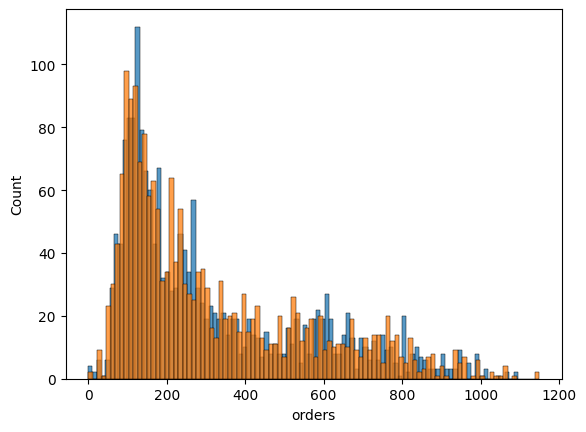

In [206]:
sns.histplot(test_aa, bins=100)
sns.histplot(control_aa, bins=100)

In [207]:
normal = np.random.normal(np.mean(test_aa_mean), np.std(test_aa_mean), len(test_aa_mean))

In [181]:
np.array(test_aa_mean)

array([309.30994152, 302.7251462 , 312.16002127, ..., 314.61244019,
       320.39872408, 308.1440723 ])

In [209]:
from scipy.stats import ttest_ind
t_statistic, p_value = ttest_ind(np.array(test_aa_mean), normal)
print(f"Значение t-статистики: {t_statistic}")
print(f"P-значение: {p_value}")

Значение t-статистики: 0.024635894217813935
P-значение: 0.9803456343405352


<Axes: ylabel='Count'>

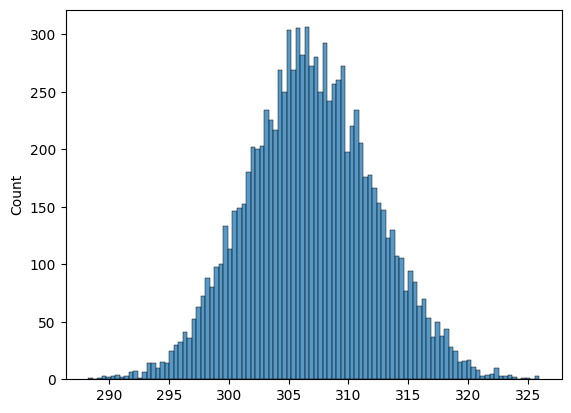

In [208]:
sns.histplot(test_aa_mean, bins=100)

In [163]:
print(np.abs(control_before.mean() - test_before.mean()))
print(np.abs(np.mean(deltas_aa)))

2.048846851298208
1.9766246865807429


In [107]:
ttest(control_before, test_before, 0)[0]

-0.27232492586866863

<Axes: ylabel='Count'>

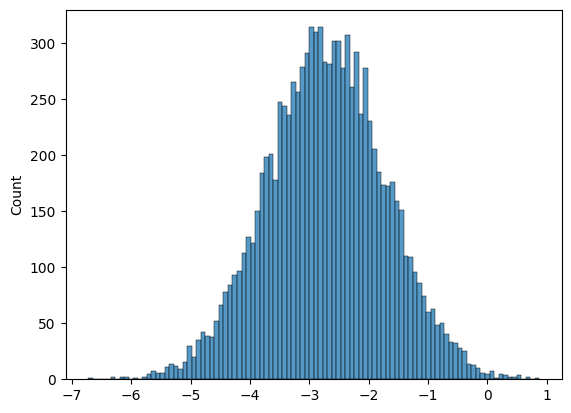

In [210]:
sns.histplot(t_ab_arr, bins=100)

<Axes: ylabel='Count'>

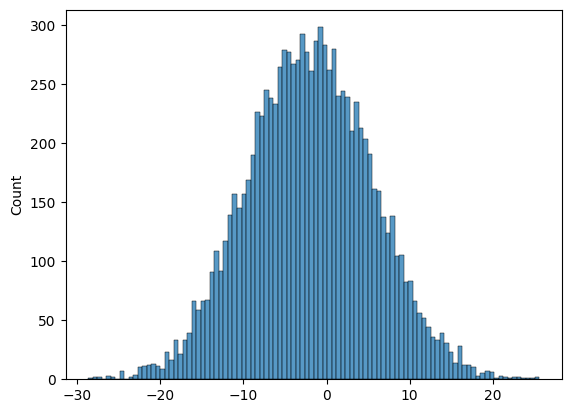

In [211]:
sns.histplot(deltas_aa, bins=100)

In [112]:
(t_aa_arr + ttest(control_before, test_before, 0)[0]).mean()

-0.535478675807652

In [115]:
np.mean(deltas_ab)

-14.274079428560825

<Axes: ylabel='Count'>

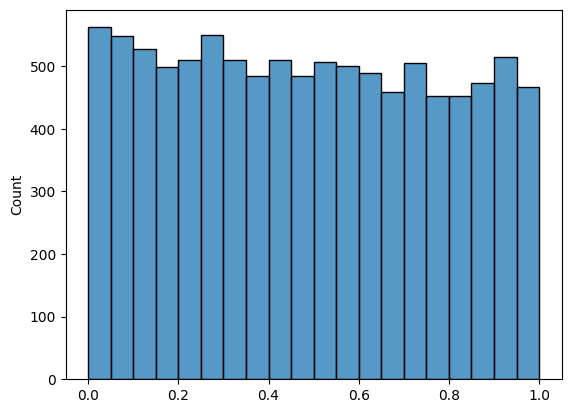

In [214]:
sns.histplot(pvalues_aa, bins=20)

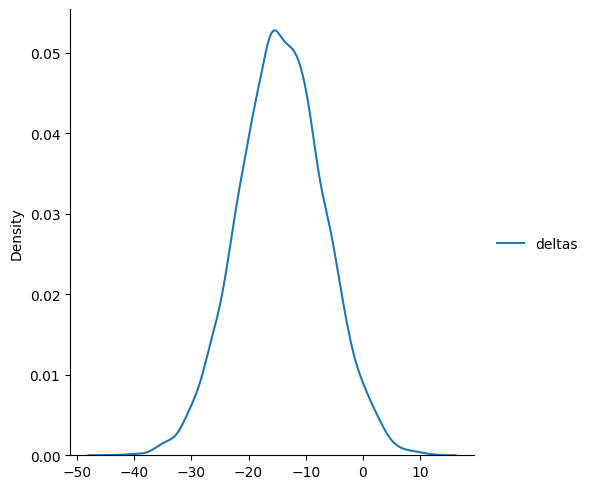

In [117]:
sns.displot(
    {'deltas': deltas_ab},
    kind='kde'
)

<Axes: >

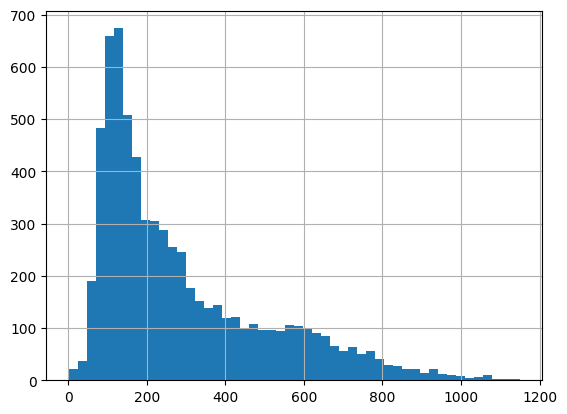

In [215]:
data[data[config['aggregator']] > 0][config['aggregator']].hist(bins=50)

<Axes: >

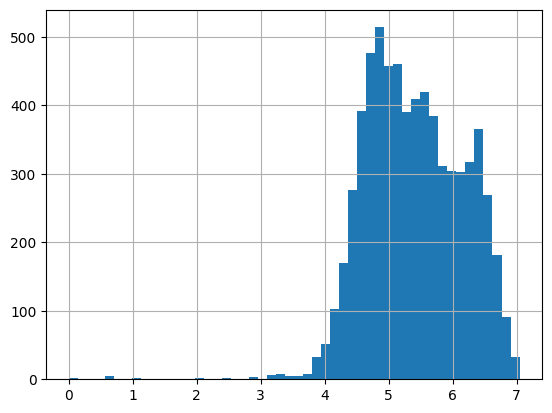

In [216]:
np.log(data[data[config['aggregator']] > 0][config['aggregator']]).hist(bins=50)

In [ ]:
data[config['aggregator']]

: 

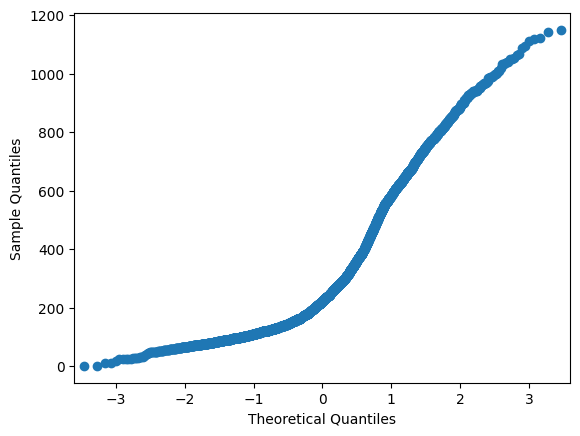

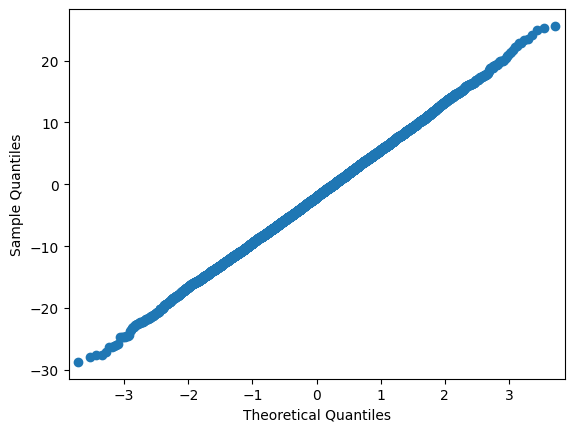

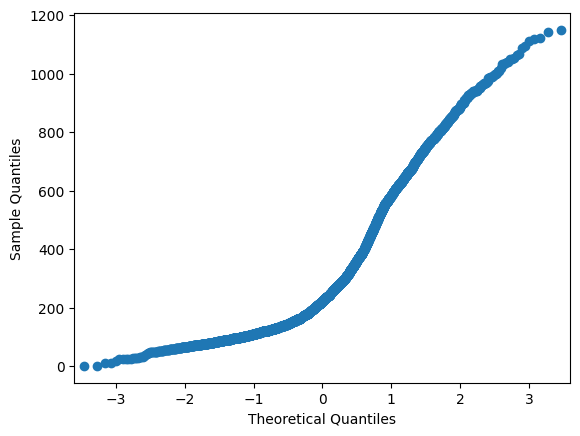

In [217]:
sm.qqplot(np.array(deltas_aa))
sm.qqplot(data[(data[config['aggregator']] > 0) & (data.event_date < common_config['start_date'])][config['aggregator']])
#sm.qqplot(np.log(data[data[config['aggregator']] > 0][config['aggregator']]))

In [219]:
import scipy.stats as stats

#Levene's test centered at the median
stats.levene(control_after.dropna(), test_after.dropna(), center='mean')


LeveneResult(statistic=0.05540675737759547, pvalue=0.8139216017716624)

In [252]:
data = data[data['event_date'] != '2024-01-04'] 

In [250]:
data[data['event_date'] == '2024-01-05']

,Unnamed: 0,event_date,restraunt_id,system_identification_only_showed,open_auth_count,tap_email_count,tap_sms_count,sessions,orders,auth_orders,conversion_rate,auth_conversion_rate,revenue,avg_product_count,strat,group


In [223]:
data.head(1)

,Unnamed: 0,event_date,restraunt_id,system_identification_only_showed,open_auth_count,tap_email_count,tap_sms_count,sessions,orders,auth_orders,conversion_rate,auth_conversion_rate,revenue,avg_product_count,avg_orders,strat,group
0,12,2023-10-01,74013270.0,0,0,0,0,927,691.0,7,0.745415,0.007551,329079.0,3.221418,784.906667,10,Test


In [253]:
a = data.copy()
a.event_date = a.event_date.str.replace('-', '')
a.strat = 0
a.to_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\real_data\active_data.csv')
splitted_data.to_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\real_data\groups.csv')

In [53]:
t = (control_after.mean() - test_after.mean()) / \
  np.sqrt(control_after.var()/control_after.action_order_success.count() + test_after.action_order_success.var()/test_after.action_order_success.count())
t

AttributeError: 'Series' object has no attribute 'action_order_success'

In [ ]:
pvalue = 2 * (1 - stats.norm.cdf(np.abs(t)))
pvalue

: 